In [23]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn, optim
from torchvision import datasets, transforms

import zipfile

import shutil
import os
import pandas as pd

device = ("cuda:0" if torch.cuda.is_available() else "cpu") # Use GPU or CPU for training
     

In [24]:
'''with zipfile.ZipFile("celeba.zip","r") as zip_ref:
  zip_ref.extractall("data_faces/")'''

'with zipfile.ZipFile("celeba.zip","r") as zip_ref:\n  zip_ref.extractall("data_faces/")'

In [27]:

root = 'data_faces/img_align_celeba'
img_list = os.listdir(root)
print(len(img_list))
     

202599


In [28]:

df = pd.read_csv("list_attr_celeba.csv")
df = df[['image_id', 'Smiling']]

In [29]:
# to make directories

'''!rm -rf data
!mkdir data && mkdir data/smile && mkdir data/no_smile'''

'!rm -rf data\n!mkdir data && mkdir data/smile && mkdir data/no_smile'

In [30]:
'''
s0 = 0
s1 = 0

num = 7000000

for i, (_, i_row) in enumerate(df.iterrows()):
  if s0 < num:
    if i_row['Smiling'] == 1:
      s0 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel1/smile/' + i_row['image_id'])
  
  if s1 < num:
    if i_row['Smiling'] == -1:
      s1 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel1/no_smile/' + i_row['image_id'])
  
  if s0 == num and s1 == num:
    break'''

"\ns0 = 0\ns1 = 0\n\nnum = 7000000\n\nfor i, (_, i_row) in enumerate(df.iterrows()):\n  if s0 < num:\n    if i_row['Smiling'] == 1:\n      s0 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel1/smile/' + i_row['image_id'])\n  \n  if s1 < num:\n    if i_row['Smiling'] == -1:\n      s1 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel1/no_smile/' + i_row['image_id'])\n  \n  if s0 == num and s1 == num:\n    break"

In [31]:

img_list = os.listdir('data_cel1/smile/')
img_list.extend(os.listdir('data_cel1/no_smile/'))

In [32]:
print("Images: ", len(img_list))


Images:  202599


In [33]:
transform = transforms.Compose([
          transforms.Resize((64, 64)),
          transforms.ToTensor()
          ])

batch_size = 64
celeba_data = datasets.ImageFolder('data_cel1', transform=transform)

In [34]:
print(celeba_data.classes)
print(len(celeba_data))

['no_smile', 'smile']
202599


In [35]:

train_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.8), len(img_list) - int(len(img_list) * 0.8)])
train_data_size = len(train_set)
test_data_size = len(test_set)

In [36]:
trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)
testLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)

In [37]:


print(train_data_size)
print(test_data_size)

162079
40520


In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from vae import VAE, VAE_big

In [39]:
image_channels = 3

print('image_channels', image_channels)

#model = VAE(image_channels=image_channels).to(device)

model = VAE_big(image_channels=image_channels).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

image_channels 3


In [40]:
def loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, size_average=False)
    KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD, BCE, KLD

In [41]:
epochs = 199


In [18]:
train_loss = []

for epoch in range(epochs):
   
    total_train_loss = 0
    # training our model
    for idx, (image, label) in enumerate(trainLoader):
        images, label = image.to(device), label.to(device)

        recon_images, mu, logvar = model(images.to(device))
        loss, bce, kld = loss_fn(recon_images.to(device), images.to(device), mu.to(device), logvar.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    print('loss', loss)
    print("Epoch : ", epoch)


    torch.save(model.state_dict(), '/home/luser/autoencoder_attacks/saved_celebA/checkpoints/celebA_CNN_VAE_big_trainSize'+str(train_data_size)+'_epochs'+str(epoch)+'.torch')

/home/luser/anaconda3/envs/inn/lib/python3.9/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


KeyboardInterrupt: 

In [42]:
model = VAE_big(image_channels=image_channels).to(device)


In [43]:
model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/checkpoints/celebA_CNN_VAE_big_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))

# Set the model to evaluation mode (if needed)
model.eval()

VAE_big(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2))
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(4, 4), stride=(2, 2))
    (13): ReLU()
    (14): Flatten()
  )
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=1024, bias=True)
  (decoder): Sequential(
    (0): UnFlatten()
    (1): ConvTranspose2d(1024, 256, kernel_size=(5, 5), stride=(2, 2))
    (2): ReLU()
    (3): ConvTranspose2d(256, 128, kern

In [44]:
for idx, (image, label) in enumerate(trainLoader):
    images, label = image.to(device), label.to(device)
    break

In [45]:
recon_images, mu, logvar = model(images.to(device))


In [46]:
recon_images.shape

torch.Size([64, 3, 64, 64])

In [47]:
selected_ind = 7

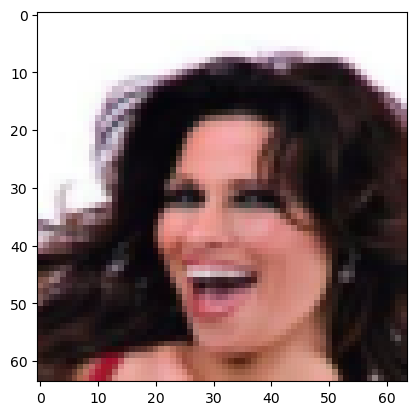

In [48]:
plt.imshow(images[selected_ind].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')


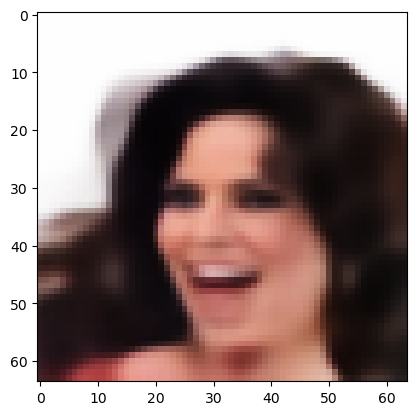

In [49]:
plt.imshow(recon_images[selected_ind].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
